# Exploratory Data Analysis: 2016 US Election (Twitter)

This notebook explores the Twitter poll dataset for the 2016 US Presidential Election.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
from pathlib import Path

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

import warnings
warnings.filterwarnings('ignore')

sys.path.append(str(Path('..').resolve()))
from bias_analysis.dataset import get_base_dataset

from loguru import logger
logger.remove()

## 1. Load US16 Dataset

In [3]:
df = get_base_dataset(election="us16")

print(f"Base dataset loaded with {len(df)} polls and {len(df.columns)} features.\n")
print(df.info())
df.head()

Base dataset loaded with 761 polls and 21 features.

<class 'pandas.DataFrame'>
RangeIndex: 761 entries, 0 to 760
Data columns (total 21 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   tweet_id                      761 non-null    str    
 1   author_id                     761 non-null    str    
 2   created_at                    738 non-null    str    
 3   tweet_text                    761 non-null    str    
 4   data_source                   761 non-null    str    
 5   duration_minutes              658 non-null    float64
 6   n_options                     761 non-null    int64  
 7   total_votes                   761 non-null    int64  
 8   poll_options                  761 non-null    str    
 9   user_id                       176 non-null    str    
 10  author_partisanship_raw       176 non-null    float64
 11  author_partisanship           176 non-null    float64
 12  user_id_demo          

,tweet_id,author_id,created_at,tweet_text,data_source,duration_minutes,n_options,total_votes,poll_options,user_id,...,author_partisanship,user_id_demo,author_org_prob,author_gender_male,author_age_under_29,author_age_30_39,author_age_40_over,audience_mean_partisanship,audience_median_partisanship,audience_n_distinct_users
0,684460173503549441,846671941,Tue Jan 05 19:43:16 +0000 2016,Theoretic poll. Current front runners in each ...,vote,1440.0,2,23,"[{'position': 1, 'label': 'Donald Trump', 'vot...",NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1,684842447160094720,None,NaN,Donald Trump vs. Hillary Clinton are both in t...,vote,1440.0,2,104,"[{'position': 1, 'label': 'Donald Trump', 'vot...",NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
2,685120449928249344,None,NaN,"If vote for US President was today, and it was...",vote,1440.0,2,4,"[{'position': 1, 'label': 'Trump', 'votes': 0}...",NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
3,685916907564855296,255242459,Sat Jan 09 20:11:49 +0000 2016,If it was down to Donald Trump and Hilary Clin...,vote,1440.0,2,10,"[{'position': 1, 'label': 'Donald Trump', 'vot...",NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
4,689848207443107840,70405708,Wed Jan 20 16:33:24 +0000 2016,Who would you vote for Trump or Clinton?,vote,1440.0,2,6,"[{'position': 1, 'label': 'Trump', 'votes': 2}...",NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0


## 2. Poll Sources and Distribution

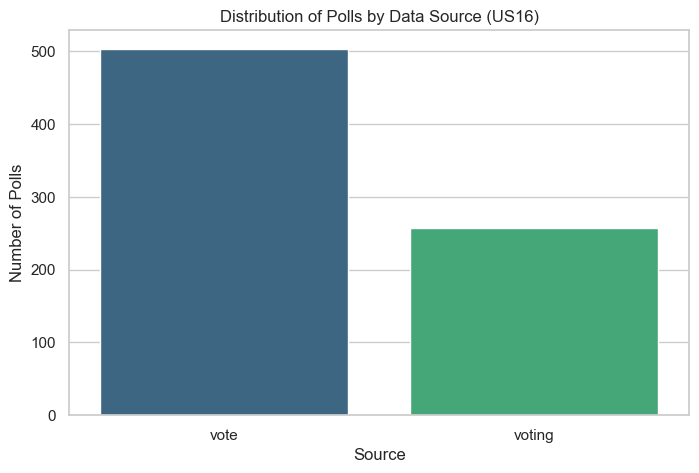

In [4]:
source_counts = df['data_source'].value_counts()

plt.figure(figsize=(8, 5))
sns.barplot(x=source_counts.index, y=source_counts.values, palette='viridis')
plt.title('Distribution of Polls by Data Source (US16)')
plt.ylabel('Number of Polls')
plt.xlabel('Source')
plt.show()

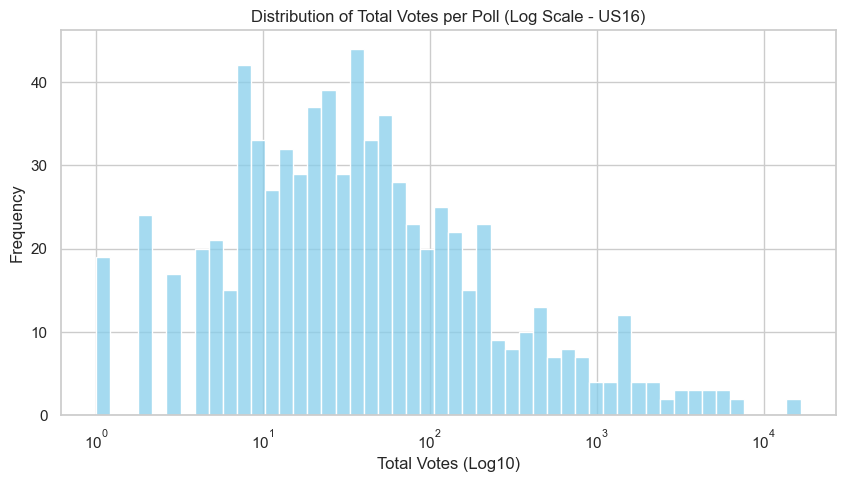

In [5]:
plt.figure(figsize=(10, 5))
sns.histplot(df['total_votes'].dropna(), bins=50, log_scale=True, color="skyblue")
plt.title('Distribution of Total Votes per Poll (Log Scale - US16)')
plt.xlabel('Total Votes (Log10)')
plt.ylabel('Frequency')
plt.show()

## 3. Author Partisanship

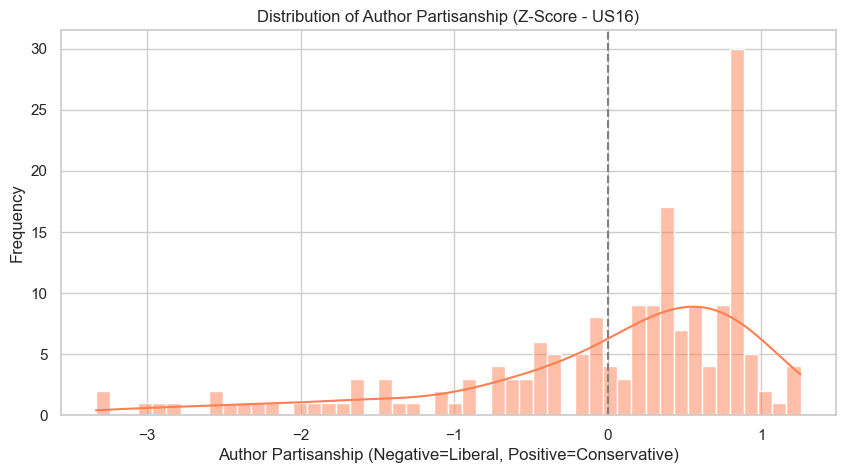

In [6]:
plt.figure(figsize=(10, 5))
sns.histplot(df['author_partisanship'].dropna(), bins=50, color="coral", kde=True)
plt.title('Distribution of Author Partisanship (Z-Score - US16)')
plt.xlabel('Author Partisanship (Negative=Liberal, Positive=Conservative)')
plt.ylabel('Frequency')
plt.axvline(0, color='gray', linestyle='--')
plt.show()

## 4. Audience Partisanship

Analyzing the distribution of the mean partisanship scores of the audience (retweeters/favoriters).

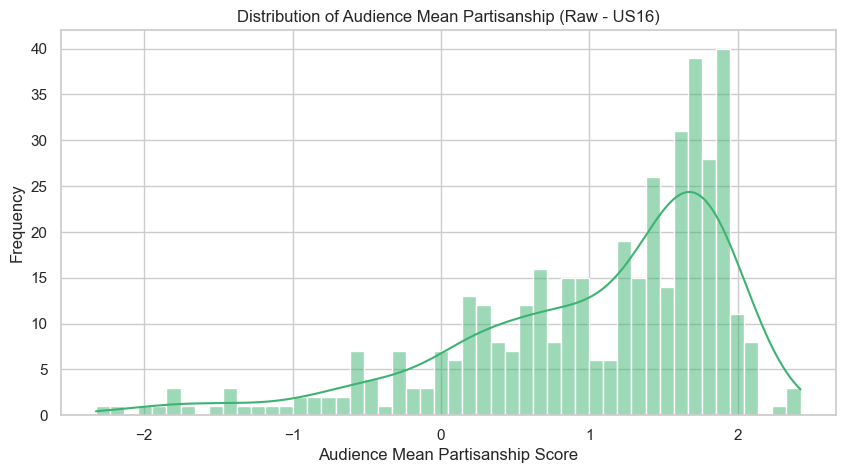

In [7]:
plt.figure(figsize=(10, 5))
sns.histplot(df['audience_mean_partisanship'].dropna(), bins=50, color="mediumseagreen", kde=True)
plt.title('Distribution of Audience Mean Partisanship (Raw - US16)')
plt.xlabel('Audience Mean Partisanship Score')
plt.ylabel('Frequency')
plt.show()

## 5. Author vs Audience Partisanship

Relationship between the poll author's inferred partisanship and their audience's mean partisanship.

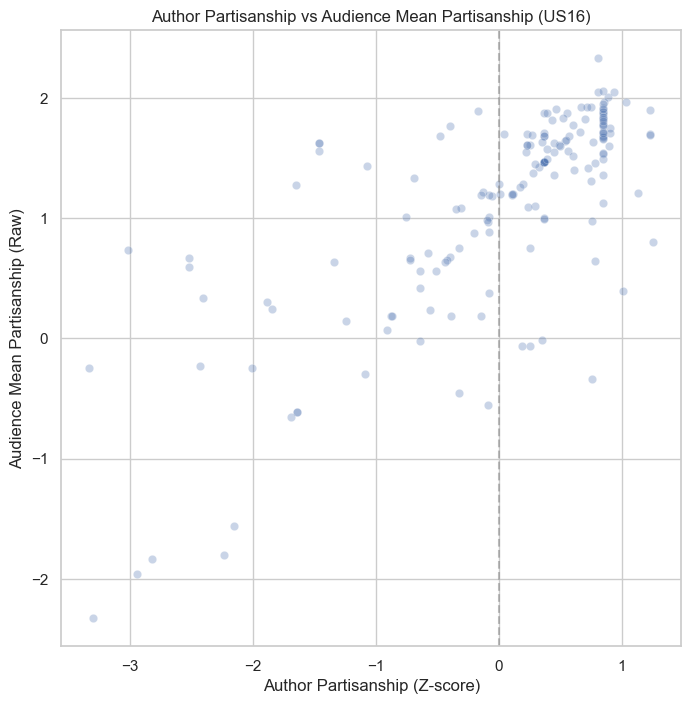

In [8]:
plot_df = df.dropna(subset=['author_partisanship', 'audience_mean_partisanship'])

plt.figure(figsize=(8, 8))
sns.scatterplot(data=plot_df, x='author_partisanship', y='audience_mean_partisanship', alpha=0.3)
plt.title('Author Partisanship vs Audience Mean Partisanship (US16)')
plt.xlabel('Author Partisanship (Z-score)')
plt.ylabel('Audience Mean Partisanship (Raw)')
plt.axvline(0, color='gray', linestyle='--', alpha=0.5)
plt.show()